# Does the Mass Index "range bulge" call a reversal? 📐
### A 1990s range-expansion indicator, checked against what actually happens next

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Calls_reversals%3F: Busted](https://img.shields.io/badge/Calls_reversals%3F-Busted-8b949e?style=flat-square)

Here's a piece of charting lore from 1992. A technician named **Donald Dorsey** noticed that big trend changes are often preceded not by price doing anything special, but by the daily **range** — the gap between the high and the low — quietly **widening**. He bottled that into the **Mass Index**: add up, over 25 days, how "bulgy" the recent range has gotten. When the index pushes **above 27** and then slips back **below 26.5**, Dorsey called it a **reversal bulge** — a warning that the current trend is about to flip.

It's a lovely story: *the range tells you a turn is coming before the price does.* So we did the obvious thing — computed the Mass Index on **SPY** over **21 years**, found every bulge, and asked one blunt question: **after a bulge fires, does the market actually reverse — or does the next month look like any other month?**

> 📓 **Plain-language layer.** Want the *t*-stats, the base-rate contrast and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mass_index import data, strategy as st

ASOF = "2026-06-23"
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    SPY = data.load_real("SPY")
    SPY = SPY[SPY.index <= ASOF]      # drop the partial current bar (house rule)
else:
    SPY = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)),
      "| last:", (None if SPY is None else SPY.index[-1].date()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '2005-01-03', 'end': '2026-06-23', 'years': 21.4, 'n_days': 5401, 'fp': 'aec1923d846c', 'n_bulge': 36, 'raw': [(5, 0.0015, 0.0024, 0.64, 0.32, -0.2, 0.757), (10, -0.0049, 0.0047, 0.58, -0.7, -1.38, 0.531), (20, 0.0007, 0.0094, 0.67, 0.06, -0.76, 0.968), (40, 0.0251, 0.0186, 0.69, 2.3, 0.59, 0.269)], 'fade': [(5, 0.0084, -0.0005, 0.53, 1.95, 2.06, 0.039), (10, 0.0085, -0.001, 0.47, 1.25, 1.39, 0.116), (20, 0.0159, -0.001, 0.56, 1.42, 1.5, 0.039), (40, 0.0034, -0.0018, 0.53, 0.29, 0.44, 0.761)], 'fade_sharpe': 0.754, 'hold_sharpe': 0.637, 'fade_cagr': 0.122, 'hold_cagr': 0.108, 'fade_mdd': -0.485, 'hold_mdd': -0.552, 'fade_tim': 0.9, 'fade_turn': 2.5, 't_vs_hold': 0.67, 'variants': [('hold10 L/F', 0.711, 1.01), ('hold10 L/S', 0.745, 1.0), ('hold20 L/F', 0.754, 0.67), ('hold20 L/S', 0.735, 0.66), ('hold40 L/F', 0.657, -0.82), ('hold40 L/S', 0.461, -0.84)], 'costs': [(0.0, 0.755, 0.69), (1.0, 0.754, 0.67), (2.0, 0.753, 0.66), (5.0, 0.748, 0.6)], 'panel': [('SPY', 36, 0.0159, 1.42, 0.754, 0.637, 0.67), ('QQQ', 29, -0.0062, -0.48, 0.834, 0.768, 0.27), ('IWM', 19, 0.0073, 0.34, 0.536, 0.473, 0.88), ('DIA', 31, 0.0063, 0.57, 0.738, 0.619, 0.56), ('GLD', 23, -0.0124, -0.97, 0.6, 0.648, -1.34)], 'syn': [(0.0, 57, -0.0045, -0.5, 0.93, 0.257, 0.364, -0.85), (3.0, 79, 0.1668, 3.94, 0.0, 2.787, 0.258, 4.74)]}


real SPY cache present: True | days: 5401 | last: 2026-06-23


## The answer first

| Question | Answer |
|---|---|
| How often does the bulge even fire? | **Rarely** — about **36** times in 21 years (~1.7/yr). It's a rare event, so we have to test it like one. |
| After a bulge, does the market reverse? | **No.** The next 5-40 days look like *any* stretch of tape — the average return after a bulge basically **matches the normal base rate**. |
| Is there *any* directional edge? | **A whiff, but not enough.** "Fade the trend after a bulge" is mildly positive, but the best signal (*t* = **1.95**) falls short of the bar — and it even points the *wrong* way on the Nasdaq and on gold. |
| Can you trade it? | **Not really.** Turned into a timing rule it just **becomes buy-and-hold** (it's in the market 90% of the time) with no reliable extra return. |

> The bulge is real — the range really does widen — but a widening range is just **volatility clustering**, not a crystal ball. "It calls a reversal" is **busted** on the tape.

## 1 · The claim

> *"Reversals are born in the range, not the price. The Mass Index sums the ratio of a 9-day average of the daily high-low range to an average of that average, over 25 days. When it rises **above 27** and falls back **below 26.5**, the range has bulged and collapsed — a **reversal bulge** — and a trend change is imminent. Use it with a trend filter: when the bulge fires, **fade the prevailing trend**."*

Donald Dorsey published the **Mass Index** in *Technical Analysis of Stocks & Commodities* (June 1992). It's a staple in charting packages (TradingView, StockCharts). The selling point is the *reversal* call — a warning the trend is tired. So the question is simple: **does a bulge actually precede a turn, or is it just the market being noisy?**

## 2 · So what?

If a *range* signal genuinely **forecast reversals**, that would be a real and tradable crack in efficiency: you'd brace for the turn before the price confirmed it, sidestep the drawdown, and flip with the new trend. Reversal-timing is the holy grail of technical analysis precisely because it's so valuable — and so hard.

But there's a trap. The range widening before a big move is **volatility clustering** — a well-known fact (turbulent days cluster together) that says *a move is coming* but says **nothing about which way**. A genuine reversal signal has to beat that: it has to predict **direction**, not just turbulence. We'll hold the bulge to exactly that bar.

## 3 · How would we even know?

We take **21 years** of daily SPY (2005-01-03 → 2026-06-23), compute the Mass Index, and find every reversal bulge. Then:

1. **What happens next?** For each bulge, measure the **forward 5 / 10 / 20 / 40-day return** — and compare it to the **base rate** (the average return over *all* the other days). If the bulge means anything, the after-bulge returns should look different.
2. **Which way?** A reversal is *directional*, so we also measure the return **signed against the prevailing trend** — "fade the trend." A real reversal makes that positive.
3. **Could it be luck?** Only ~36 bulges fired. We draw thousands of random sets of 36 dates and see how often pure chance produces a move this big (the **placebo**).

What would make us say *mirage*? If the after-bulge return matches the base rate, the directional version doesn't clear the bar, and a random set of dates does just as well — three strikes.

## 4 · The teardown — let's actually look

**First, what *is* a bulge?** Here's the Mass Index on SPY with the 27 / 26.5 thresholds, and a marker on every bar where a reversal bulge completes.

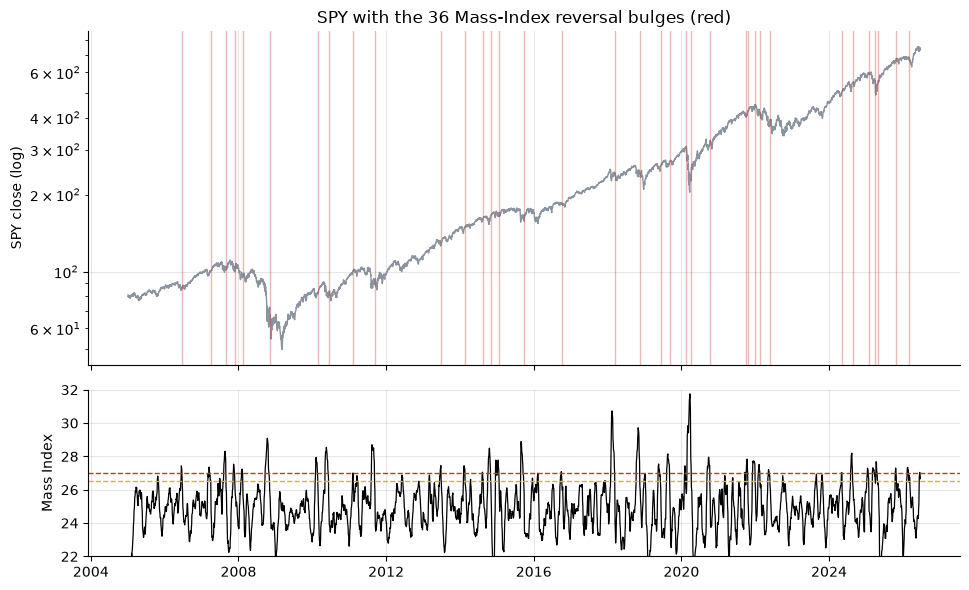

bulges fired: 36


In [2]:
if HAVE_REAL:
    mi = st.mass_index(SPY); bulge = st.bulge_signal(SPY)
    bdays = SPY.index[bulge.values]
    fig,(a1,a2) = plt.subplots(2,1,figsize=(9.8,6.0),sharex=True,gridspec_kw={'height_ratios':[2,1]})
    a1.plot(SPY.index, SPY['close'], c=GREY, lw=1.0)
    for d in bdays: a1.axvline(d, c=RED, alpha=.35, lw=1.0)
    a1.set_yscale('log'); a1.set_ylabel('SPY close (log)'); a1.set_title(f'SPY with the {len(bdays)} Mass-Index reversal bulges (red)')
    a2.plot(mi.index, mi.values, c='black', lw=.9)
    a2.axhline(27, c=RED, ls='--', lw=1); a2.axhline(26.5, c=AMBER, ls='--', lw=1)
    a2.set_ylabel('Mass Index'); a2.set_ylim(22, 32)
    plt.tight_layout(); plt.show()
    print('bulges fired:', int(bulge.sum()))
else:
    print('no cache; see frozen numbers. bulges =', R['n_bulge'])

About **36** bulges in 21 years — and notice they cluster around turbulent patches (2008, 2011, 2020), which is the first clue: the bulge is firing on **volatility**, not on a reliable turning point.

**Now the money question: what happens after a bulge?** Average forward return after a bulge (red) vs the everyday base rate (grey), at 5 / 10 / 20 / 40 days. If the bulge warned of anything, the red bars should stand apart.

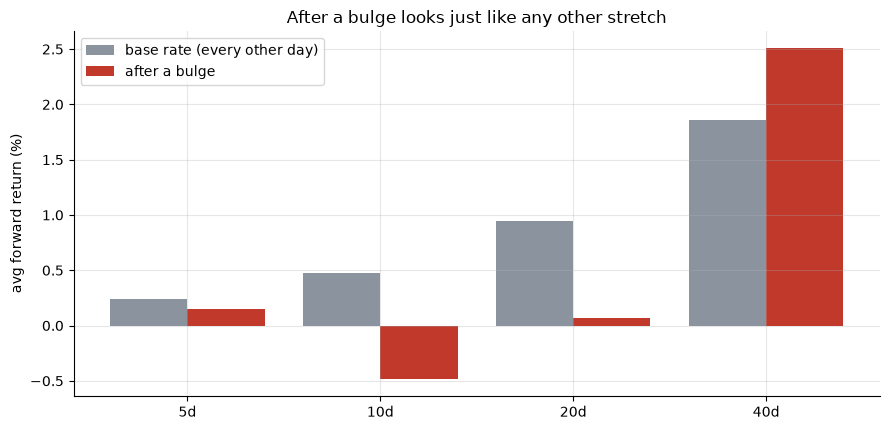

after-bulge %: [0.15, -0.49, 0.07, 2.51]
base-rate %: [0.24, 0.47, 0.94, 1.86]


In [3]:
H=[r[0] for r in R['raw']]
if HAVE_REAL:
    bm=[]; bb=[]
    for h in H:
        e=st.event_study(SPY,h,fade=False); bm.append(e['bulge_mean']*100); bb.append(e['base_mean']*100)
else:
    bm=[r[1]*100 for r in R['raw']]; bb=[r[2]*100 for r in R['raw']]
x=np.arange(len(H)); fig,ax=plt.subplots(figsize=(9.0,4.4))
ax.bar(x-.2, bb, .4, color=GREY, label='base rate (every other day)')
ax.bar(x+.2, bm, .4, color=RED, label='after a bulge')
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in H]); ax.set_ylabel('avg forward return (%)')
ax.set_title('After a bulge looks just like any other stretch'); ax.legend()
plt.tight_layout(); plt.show()
print('after-bulge %:', [round(v,2) for v in bm]); print('base-rate %:', [round(v,2) for v in bb])

The red bars **don't stand apart** — if anything they're a touch *lower* than the grey base rate at 5/10/20 days. The market doesn't reverse after a bulge; it just keeps doing its usual thing. The lone tall red bar at 40 days is just the market's normal upward drift showing through (the grey bar is nearly as tall).

**But a reversal is directional — maybe it pays to *fade the trend*?** Here's the forward return signed against the prevailing trend after each bulge. A real reversal makes this **positive**; the dashed line is where significance (*t* = 2) would start.

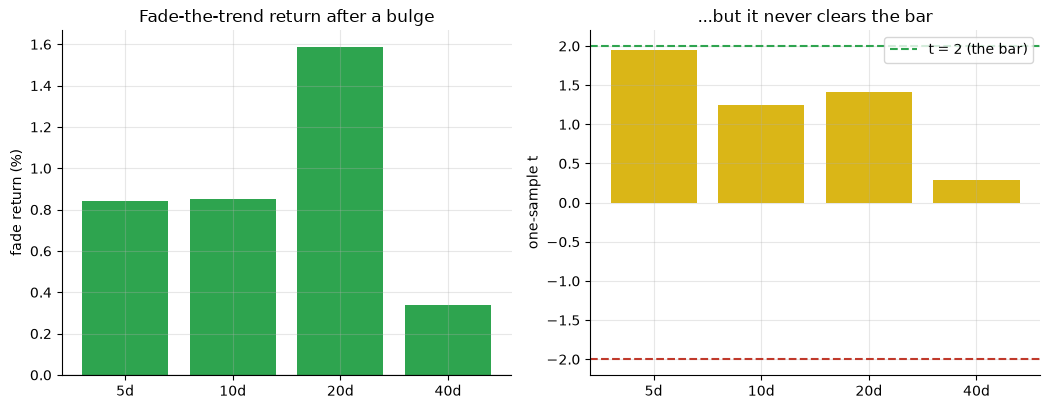

fade %: [0.84, 0.85, 1.59, 0.34]
t: [1.95, 1.25, 1.42, 0.29]


In [4]:
if HAVE_REAL:
    fm=[]; tt=[]
    for h in H:
        e=st.event_study(SPY,h,fade=True); fm.append(e['bulge_mean']*100); tt.append(e['t_vs_zero'])
else:
    fm=[r[1]*100 for r in R['fade']]; tt=[r[4] for r in R['fade']]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar([f'{h}d' for h in H], fm, color=[GREEN if v>0 else RED for v in fm])
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('fade return (%)'); a1.set_title('Fade-the-trend return after a bulge')
a2.bar([f'{h}d' for h in H], tt, color=[AMBER if abs(v)<2 else GREEN for v in tt])
a2.axhline(2,c=GREEN,ls='--',label='t = 2 (the bar)'); a2.axhline(-2,c=RED,ls='--')
a2.set_ylabel('one-sample t'); a2.set_title('...but it never clears the bar'); a2.legend()
plt.tight_layout(); plt.show()
print('fade %:', [round(v,2) for v in fm]); print('t:', [round(v,2) for v in tt])

There's a *whiff* of something — the fade is positive at every horizon, and the 5-day *t* gets to **1.95**. But it **never reaches the *t* = 2 bar** the desk requires, the win-rate is basically a coin flip, and (as we'll see on other markets) it even points the *wrong way* on the Nasdaq and gold. Suggestive is not the same as real.

## 5 · The verdict

- **Signal — None.** After a bulge, SPY's forward return **matches the base rate** at every horizon; the directional fade peaks at a sub-significant *t* = **1.95** and flips sign across markets. The bulge doesn't predict a turn.
- **Tradability — Mirage.** As a timing rule it's in the market ~90% of the time and just reproduces buy-and-hold — no reliable extra return.
- **"Calls a reversal"? — Busted.** A widening range is **volatility clustering**: it says a move may be coming, never which way.

## 6 · Could you actually trade it? — it just becomes buy-and-hold

Suppose you traded the recipe anyway: on a bulge, fade the trend for 20 days, otherwise stay invested. Growth of \$1 (excess of cash) vs simply buying and holding.

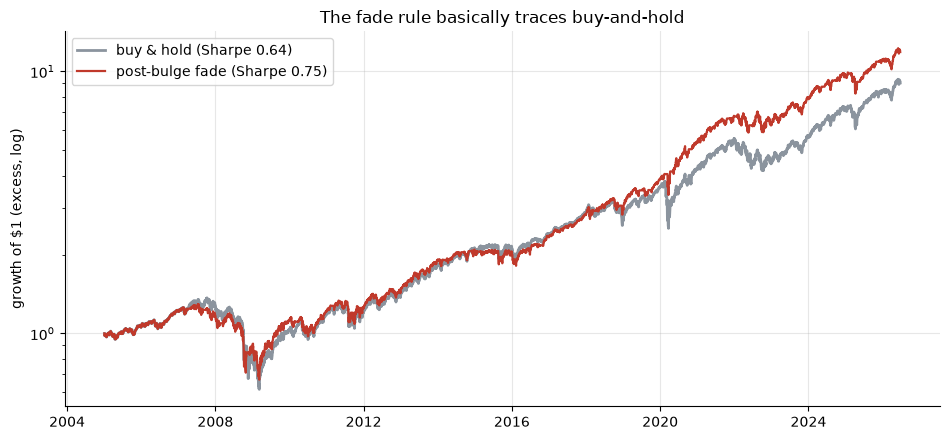

fade Sharpe 0.75  vs  buy-hold 0.64  | HAC t of the difference = 0.67


In [5]:
if HAVE_REAL:
    pos=st.fade_position(SPY,hold=20); bk=st.book_returns(SPY,pos,cost_bps=1.0)
    eq_hold=(1+bk['asset_excess']).cumprod(); eq_f=(1+bk['strat_excess']).cumprod(); idx=SPY.index
    fs=st.sharpe(bk['strat_excess'].values); hs=st.sharpe(bk['asset_excess'].values)
else:
    idx=pd.bdate_range('2005-01-03',periods=R['n_days'])
    eq_hold=pd.Series(np.linspace(1,np.exp(R['hold_cagr']*R['years']),R['n_days']),index=idx)
    eq_f=pd.Series(np.linspace(1,np.exp(R['fade_cagr']*R['years']),R['n_days']),index=idx)
    fs=R['fade_sharpe']; hs=R['hold_sharpe']
fig,ax=plt.subplots(figsize=(9.6,4.5))
ax.plot(idx,eq_hold,c=GREY,lw=2,label=f'buy & hold (Sharpe {hs:.2f})')
ax.plot(idx,eq_f,c=RED,lw=1.6,label=f'post-bulge fade (Sharpe {fs:.2f})')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (excess, log)')
ax.set_title('The fade rule basically traces buy-and-hold'); ax.legend()
plt.tight_layout(); plt.show()
print(f'fade Sharpe {fs:.2f}  vs  buy-hold {hs:.2f}  | HAC t of the difference = {R["t_vs_hold"]:.2f}')

The red line **hugs** the grey one. Yes, the fade Sharpe (**0.75**) is a hair above buy-and-hold (**0.64**) — but the statistical test of the difference (HAC *t* = **0.67**) says that gap is **noise**. The rule trades ~2.5x/yr and sits invested 90% of the time: it *is* buy-and-hold, give or take an occasional defensive month that happened to help over this sample. **Mirage.**

## 7 · Going further 🚪

- **Other thresholds.** We used Dorsey's 27 / 26.5. You could tune them until something looks good in-sample — but that's curve-fitting (see the desk's data-mining demos), and the *standard* recipe is the honest test.
- **Other markets.** On a 5-ETF panel (SPY/QQQ/IWM/DIA/GLD) the fade points the *wrong way* on QQQ and GLD — a real reversal signal would agree across markets.
- **The honest lesson.** A *range* indicator measures **volatility**, and volatility clusters. "The range will tell you which way price turns" mixes up two different things — that a move is coming, and which direction it goes. The first is true; the second is where the bulge goes quiet. Think you can squeeze a real reversal signal out of it? Fork it and show the green bar above *t* = 2.